# ラベルの予測精度の評価

書籍では異常検知の性能評価手法を⼤きく、「**1.ラベルの予測精度**」、「**2.統計モデル選択の妥当性**」という二つのアプローチに分けて解説しました。

両評価指標の特徴は、以下のようにまとめられます。

||1.ラベルの予測精度|2.統計モデル選択の妥当性|
|---|---|---|
|適用できる異常検知アルゴリズム|教師あり学習、教師なし学習・統計モデリング（異常データが取得可能な場合）|教師なし学習・統計モデリング|
|評価指標の測定内容|ラベルの予測誤差|モデルのデータへの適合度|
|異常検知における評価目的|異常と正常を正しく見分けられるか|モデルがデータをどれだけうまく説明しているか|
|評価に必要なデータ|正常データ＋異常データ|正常データ|
|メリット|ビジネス上のメリットを直接評価できる|異常データなしで計算可能|
|デメリット|異常データがないと計算できない|ビジネス上のメリットに対する直接性が低い|
|代表的な評価指標|精度、適合率、再現率、F値、AU-ROC|対数尤度、AIC、BIC、WAIC|

このnotebookでは、「**1.ラベルの予測精度**」による性能評価の実装方法を解説します。この評価方法は**ビジネス上のメリットを直接評価できる**というメリットを持つ代わりに、**異常データがないと計算できない**というデメリットを持ちます。異常データさえ十分に取得できれば、複数のモデルの中からデータに適合したモデルを選択する**モデル選択と、モデルの導入効果の評価療法に活用することができます**。このように実務へのインパクトがダイレクトかつ多用途に用いることができる指標であるため、この評価を行うためにも異常データを多く取得する価値があると言えるでしょう。

具体的には、次の性能指標のPythonによる計算方法を解説します。

- 精度（Accuracy）
- 適合率（Precision）
- 再現率（Recall）
- F 値（F-score）
- AU-ROC

性能評価の実装法は、モデルのライブラリやデータセットの特性により変わるため、ここでは以下の4パターンそれぞれについて評価方法を解説します。

1. 教師なし学習モデル（NumPyのスクラッチ実装モデル）を用いる場合
2. 教師あり学習モデル（scikit-learn）を用いる場合
3. 統計モデリング（statsmodels）を用いる場合
4. ベイズ統計モデリング（PyMC）を用いる場合

## 1. 教師なし学習モデル（NumPyのスクラッチ実装）を用いる場合

この例では、4章から6章で解説した教師なし学習モデルを用いるケースを想定します。モデルをNumPyでスクラッチ実装しているため、実装にやや手間はかかりますが、評価の詳細な流れを追いやすい例と言えます。

ここでは、2章で作成したサンプルデータと、6章で解説した2変数のホテリング理論（正規分布）のモデルを用います。以下に示すように、[ch6_3_Multivariate_Hotelling.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch6_3_Multivariate_Hotelling.ipynb)で学習データを用いて学習したモデルのパラメータを用い、推論用データを指標算出用のテストデータとして使用します。

In [10]:
# コード9.7 性能評価指標算出に使用するデータとモデル
import pandas as pd
import numpy as np

# モデルのパラメータ（6章で学習済み）
MU = [350.23771153, 400.21552883] # 標本平均ベクトルμ
SIGMA = [[26.04088919, 14.52874949],
[14.52874949, 24.58401158]] # 標本分散共分散行列Σ
A_TH=11.82900701194368 # 異常度のしきい値

# CSVからPandas DataFrameにテストデータ読み込み
df_test = pd.read_csv("./datasets/ch2_dataset_inference.csv")
# "temp2","temp1"変数に欠測が含まれるデータを削除
df_test = df_test.dropna(subset=["temp2", "temp1"])
X_val = df_test[["temp2", "temp1"]].to_numpy()
# 正解ラベル（'normal' or 'anomaly'）
y_true = df_test["label"].to_numpy()
# 異常度を算出（式6.45に従う）
X_dev = (X_val-np.array(MU)).T # 推論データと平均ベクトルとの差（x-μ）
Sigma_inv = np.linalg.inv(np.array(SIGMA)) # 標本分散共分散行列の逆行列
Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1)
# しきい値により異常の有無を推論
y_pred = np.where(anomaly_scores > A_TH, 'anomaly', 'normal')

参考として、テストデータと学習済みモデルの決定境界をプロットしてみます。

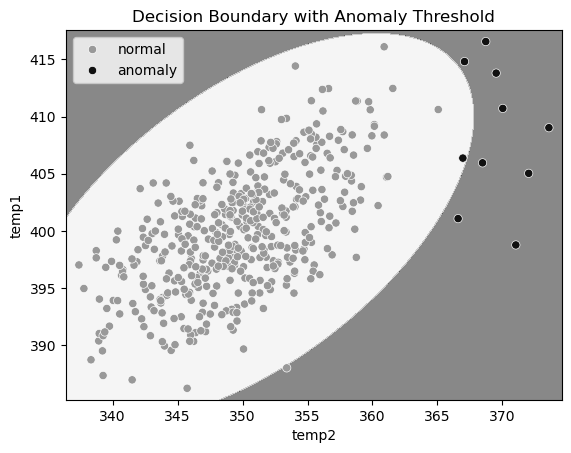

In [11]:
# 決定境界をプロット
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(mu, sigma, a_th, X, y, ax=None):
    if ax is None:
        ax = plt.gca()
    # グリッドを作成
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    # 各点の異常度を計算
    X_dev = (X_grid - np.array(mu)).T  # (x-μ)
    Sigma_inv = np.linalg.inv(np.array(sigma))  # Σ^-1
    Dev_Sigma = X_dev.T @ Sigma_inv  # (x-μ)^T * Σ^-1
    anomaly_scores_grid = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1)
    # しきい値により異常の有無を決定
    Z = np.where(anomaly_scores_grid > a_th, 'anomaly', 'normal')
    Z_numeric = np.where(Z == 'anomaly', 0, 1)
    Z_numeric = Z_numeric.reshape(xx.shape)
    # 決定境界を描画
    ax.contourf(xx, yy, Z_numeric, alpha=0.5, cmap=cm.gray)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette=['#999999', '#111111'], ax=ax)
    ax.set_xlabel('temp2')
    ax.set_ylabel('temp1')
plot_decision_boundary(MU, SIGMA, A_TH, X_val, y_true)
plt.title('Decision Boundary with Anomaly Threshold')
plt.show()

散布図がテストデータ（凡例の色分けが正解ラベル）、背景の塗りつぶしがモデルの予測結果（決定境界）を表しており、両者の判定が一致しているほど性能が高いと言えます。図からこのモデルは正解と判定の一致度が高いことが見てとれるため、良い性能指標の算出が期待されます。

### 参考：混同行列の計算

「1.ラベルの予測精度」に属する評価指標の計算では一般的に、最初のステップとして正しく判別できたかを整理するための混同行列（confusion matrix）を作成します。



後述するようにscikit-learnを用いれば、混同行列を明示的に求めることなく各種指標を求められますが、参考として混同行列を求める方法を以下に示します。

In [12]:
# 混同行列の計算
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=['normal', 'anomaly'])
cm_df = pd.DataFrame(cm, index=['normal', 'anomaly'], columns=['pred_normal', 'pred_anomaly'])
cm_df

,pred_normal,pred_anomaly
normal,449,1
anomaly,1,9


TP,TNの割合が非常に高く、FP,FNはそれぞれ1例しか観測されていないことが分かります。FPは先ほどの散布図が白（正解が正常）かつ塗りつぶしが黒（判定が異常）、FNは散布図が黒（正解が異常）かつ塗りつぶしが白（判定が正常）のデータを表します。FP,FNが少ないことは、先ほどプロットした図で判定間違いが少なかった結果と一致しています。

ここから実際の評価指標を求めていきます。

### 精度（Accuracy）

**精度**（accuracy）は、モデルで予測されたラベルが実際の正解ラベルと一致した割合を表す指標で、以下の式で表されます。

$Accuracy=\frac{TP+TN}{TP+FP+TN+FN}$

精度は**誤報と見逃しを同時に評価**でき、また直感的に理解しやすいことから、簡易的な評価指標として広く用いられています。
一方で、正常と異常の数に偏りがある**不均衡データの場合、数が少ない方のラベルをほとんど考慮できない**という欠点を持ちます。このような不均衡データにおいては、例えばすべてのデータを正常と判定する不適切なモデルに対しても、高い精度が出てしまいます。これは異常を正常と判定する見逃し（FN）に鈍感であることを表しています。

Pythonでは、scikit-learnの[sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)関数で精度を計算できます。

In [13]:
# コード9.8 精度の計算
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.996


今回の例ではscikit-learnの`accuracy_score`関数を使用しましたが、先ほど計算した混同行列から求めたTP,FP,TN,FNを用いて式に基づき計算することもできます（以後紹介する適合率、再現率、F値も同様）。

### 適合率（precision）

**適合率**（precision）は、モデルが陽性（異常検知においては異常）と判定したデータのうち、実際のラベルも陽性であった割合を表す指標で、以下の式で表されます。

$Accuracy=\frac{TP}{TP+FP}$

適合率はFPとFNのうち、FPのみを考慮に入れています。これは異常検知においては、誤報と見逃しのうち**誤報のみを評価する指標**と言えます。

Pythonでは、scikit-learnの[sklearn.metrics.precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)関数で適合率を計算できます。この際、正例のラベルを`pos_label`引数に指定する必要があります。

In [14]:
# コード9.9 適合率の計算
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred, pos_label='anomaly')
print(f"Precision: {precision:.3f}")

Precision: 0.900


FP（誤報）が1例しか存在しないので、適合率が1.0（100%）に近い良い値となっていることが分かります。

### 再現率（recall）

**再現率**（recall）は、実際のラベルが陽性（異常検知においては異常）であるデータのうち、モデルが正しく陽性と判定した割合を表す指標で、以下の式で表されます。

$Recall=\frac{TP}{TP+FN}$

再現率は適合率とは逆に、**見逃しのみを評価する指標**です。特に医療や高価格製品の検査などでは、一つの見逃しであっても多⼤な損失を生み出すことがあるため、再現率を重視した性能評価が重要となります。

Pythonでは、scikit-learnの[sklearn.metrics.recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)関数で精度を計算できます。適合率と同様に、正例のラベルを`pos_label`引数に指定する必要があります。

In [15]:
# コード9.10 再現率の計算
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred, pos_label='anomaly')
print(f"Recall: {recall:.3f}")

Recall: 0.900


FN（見逃し）が1例しか存在しないので、再現率が1.0（100%）に近い良い値になっていることが分かります。

### F値（F-score）

**F値**（F-score）は、適合率と再現率の調和平均として求められる指標で、以下の式で表されます。

$Fscore=\frac{2\times Precision \times Recall}{Precision+Recall}$

F値は誤報と**見逃しの両方を同時に評価**でき、かつ**精度と比べて不均衡データに強い**という特徴を持ちます。例えばすべてのデータを正常と判定する不適切なモデルに不均衡データを入力すると、精度は高い値が算出されましたが、F値では低い値が算出されます。したがってF値は、不均衡データを入力することが多い**異常検知の簡易評価に適した指標**と言えるでしょう。

Pythonでは、scikit-learnの[sklearn.metrics.f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)関数で精度を計算できます。適合率や再現率と同様に、正例のラベルを`pos_label`引数に指定する必要があります。

In [16]:
# コード9.11 F値の計算
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, pos_label='anomaly')
print(f"F1 Score: {f1:.3f}")

F1 Score: 0.900


今回のデータは異常データ10個中1個が見逃されており（再現率0.9）、見逃しを防ぐという観点では必ずしも良い結果とは言えませんが、精度では0.996という非常に高い値が出ていました。これは前述のように、精度が見逃しに鈍感な指標であることに起因します。これに対してF値は0.9とそれよりは低い値が出ており、より見逃しを考慮に入れられていることがわかります。

### AU-ROC

**AU-ROC**（area under receiver operating characteristic curve） またはROC AUC（receiver operating characteristic area under the curve）は、**見逃しの両方を同時に評価**でき、かつ**しきい値を変えた際の性能変化も考慮に入れられるロバストな評価指標**です。

適合率と再現率、すなわち誤報と見逃しにはトレードオフ関係があるため、このトレードオフ関係をしきい値を変化させて連続的に評価することで、AU-ROCが求められます。
まずはトレードオフ関係の可視化・評価するために使用する、PR曲線とROC曲線について解説します。

#### PR曲線とROC曲線

誤報と見逃しのトレードオフ関係を可視化するため、横軸に再現率を、縦軸に適合率をとり、各しきい値における両者の値をプロットしたグラフを、**PR曲線**（precision-recall curve）と呼びます。
PR曲線のイメージをつかむため、Pythonで実際にプロットしてみます。PR曲線はscikit-learnの[sklearn.metrics.precision_recall_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html)関数で実装できます。

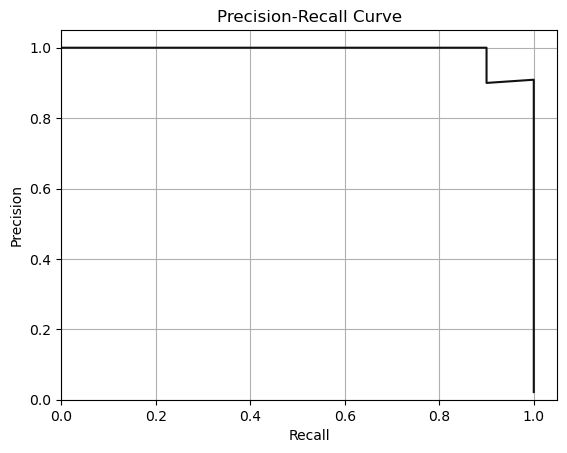

In [17]:
# コード9.12 PR 曲線の計算と可視化
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# PR曲線の計算
precision, recall, thresholds_pr = precision_recall_curve(
y_true, anomaly_scores, pos_label='anomaly')
# 計算したPR曲線を描画
plt.plot(recall, precision, color='#111111')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid()
plt.show()

なお、`precision_recall_curve`関数（後述の`roc_curve`関数も同様）の第2引数には、しきい値判定の対象となる連続値のスコアを渡します。今回のような教師なし異常検知モデルでは異常度の配列（`anomaly_scores`）を渡しますが、例えば後述の教師あり学習モデルではクラス確率`predict_proba`を渡すなど、モデルの種類によって渡すべきスコアが変わります。

今回は再現率・適合率どちらも高く、若干傾向が把握しにくいですが、左上から右下にかけてのグラフの変化からトレードオフ関係が読み取れます。

PR曲線と同じ用途で用いられるグラフとして、ROC曲線（receiver operating characteristic curve：受信者操作特性曲線）が挙げられます。ROC曲線は縦軸に再現率を、横軸に以下の式で表されるFPRをプロットしたグラフです。

$FPR=\frac{FP}{FP+TN}$

FPRは適合率と同様、FPすなわち誤報の多さを評価する指標です。ROC曲線はPR曲線と同様に、誤報と見逃しのトレードオフ関係の可視化に用いることができます。

ROC曲線はscikit-learnの[sklearn.metrics.roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)関数で実装できます。

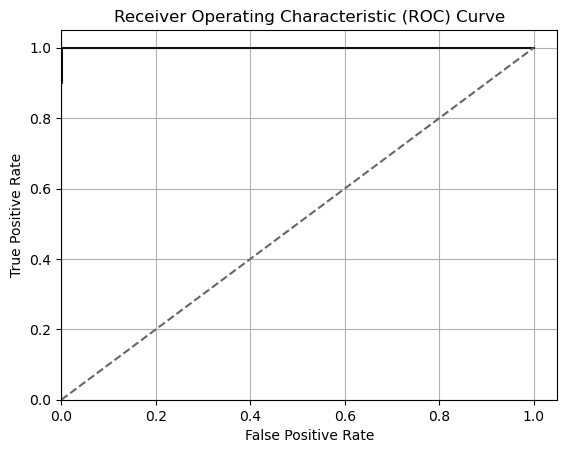

In [18]:
# コード9.13 ROC 曲線の計算と可視化
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(
y_true, anomaly_scores, pos_label='anomaly')
plt.plot(fpr, tpr, color='#111111', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='#666666', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid()
plt.show()

PR曲線と比べてさらに傾向を把握しにくいですが、より性能の低いモデルであれば左下から右上にかけてのトレードオフ関係が読み取れます。

#### AU-ROCの計算・実装方法

AU-ROCは以下の図に示すように、ROC曲線の下側の面積を表す指標です。

PythonでAU-ROCは、先ほど用いた[sklearn.metrics.roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)関数でROC曲線を計算したのち、[sklearn.metrics.auc](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html)関数で下側の面積を求めることで計算できます。

In [19]:
# コード9.14 AU-ROC の計算
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds_roc = roc_curve(y_true, anomaly_scores, pos_label='anomaly')
auroc = auc(fpr, tpr)
print(f"Area Under the ROC Curve (AU-ROC): {auroc:.4f}")

Area Under the ROC Curve (AU-ROC): 0.9998


## 2. 教師あり学習モデル（scikit-learn）を用いる場合

この例では、3章で解説した教師なし学習モデルを用いるケースを想定します。モデルも評価指標の計算もscikit-learnを用いるため、ライブラリの枠内で簡単に実装することができますが、反面評価の詳細な流れは追いにくい例と言えるでしょう。

ここでは、2章で作成したサンプルデータと、3章で解説した2変数のロジスティック回帰モデルを用います。以下に示すように、学習データを用いて学習したモデル（scikit-learnのインスタンス）を用い、推論用データを指標算出用のテストデータとして使用します。

In [20]:
# 性能評価指標算出に使用するデータとモデル
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# モデルの学習
df_train = pd.read_csv("./datasets/ch2_dataset_train.csv")  # 学習データ読み込み
df_train = df_train.dropna(subset=['temp2', 'temp1'])  # 欠測値削除
X = df_train[["temp2","temp1"]].to_numpy() # 説明変数（2変数のみ使用）
y = df_train["label"].to_numpy() # ラベルデータ（目的変数）
clf = LogisticRegression(penalty=None)
clf.fit(X, y)

# CSVからPandas DataFrameにテストデータ読み込み
df_test = pd.read_csv("./datasets/ch2_dataset_inference.csv")
# "temp2","temp1"変数に欠測が含まれるデータを削除
df_test = df_test.dropna(subset=["temp2", "temp1"])
X_val = df_test[["temp2", "temp1"]].to_numpy()
# 正解ラベル（'normal' or 'anomaly'）
y_true = df_test["label"].to_numpy()
# 推論を実施
y_pred = clf.predict(X_val)

参考として、テストデータと学習済みモデルの決定境界をプロットしてみます。

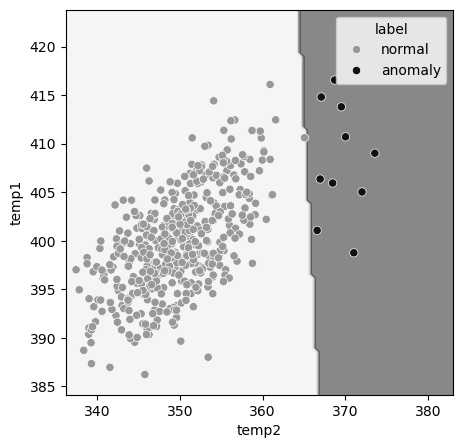

In [21]:
# 決定境界をプロット
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
disp = DecisionBoundaryDisplay.from_estimator(
    clf, X, response_method="predict",
    xlabel="temp2", ylabel="temp1",
    cmap=cm.gray, alpha=0.5, ax=ax)
# 散布図を重ねてプロット
sns.scatterplot(data=df_test, x="temp2", y="temp1",
                hue="label", palette=["#999999", "#111111"],
                ax=ax)
plt.show()

テストデータの正解（散布図の色分け）とモデルの予測結果（背景の塗りつぶし）が完全に一致しており、全てのデータが正しく判定されていることが分かります。

これはモデルの性能が極めて高いことを示唆する一方で、過学習や評価データの不足・偏りによりこのような高い性能が観測されるケースも頻繁にみられます。よってあまりに判定が良すぎる場合は、注意して結果を再確認し、必要に応じてデータのN増しや評価方法の見直しを行う必要があります。
ここではこのような全ての判定が正しいケースでどのような指標が得られるかを確認するためにも、このまま評価指標の算出を進めます。

### 参考：混同行列の計算

scikit-learnの[sklearn.metrics.confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)関数で混同行列を求めます

In [22]:
# 混同行列の計算
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=['normal', 'anomaly'])
cm_df = pd.DataFrame(cm, index=['normal', 'anomaly'], columns=['pred_normal', 'pred_anomaly'])
cm_df

,pred_normal,pred_anomaly
normal,450,0
anomaly,0,10


全てTP,TNで、FP,FNは観測されていません。FP,FNが観測されないことは、先ほどプロットした図で判定が全て正しかった結果と一致しています。

### 精度（Accuracy）

scikit-learnの[sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)関数で精度を求めます。

In [23]:
# 精度の計算
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 1.000


全ての判定が正しいので、精度が1.0（100%）となっていることが分かります。

### 適合率（precision）

scikit-learnの[sklearn.metrics.precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)関数で適合率を求めます。

In [24]:
# 適合率の計算
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred, pos_label='anomaly')
print(f"Precision: {precision:.3f}")

Precision: 1.000


全ての判定が正しいので、適合率が1.0（100%）となっていることが分かります。

### 再現率（recall）

scikit-learnの[sklearn.metrics.recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)関数で再現率を求めます。

In [25]:
# 再現率の計算
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred, pos_label='anomaly')
print(f"Recall: {recall:.3f}")

Recall: 1.000


全ての判定が正しいので、再現率が1.0（100%）となっていることが分かります。

### F値（F-score）

scikit-learnの[sklearn.metrics.f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)関数でF値を求めます。

In [26]:
# F値の計算
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, pos_label='anomaly')
print(f"F1 Score: {f1:.3f}")

F1 Score: 1.000


全ての判定が正しいので、F値が1.0（100%）となっていることが分かります。

### AU-ROC

AU-ROCを求めるための前段階として、まずscikit-learnの[sklearn.metrics.roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)関数でROC曲線を求めて可視化します。

`precision_recall_curve`の第2引数には、しきい値判定の対象となる連続値のスコアとして、`predict_proba`メソッドで求めたクラス確率を渡します。

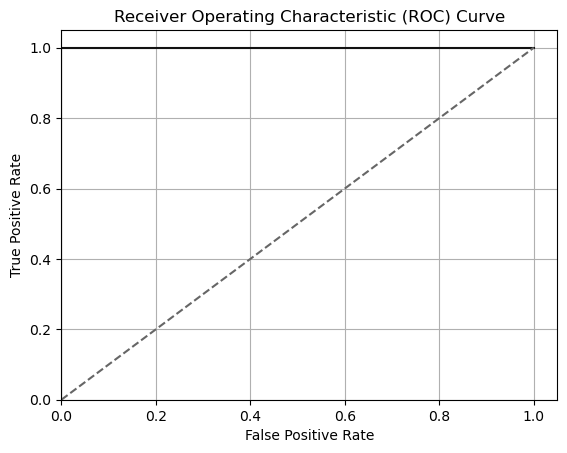

In [27]:
# ROC曲線の計算と可視化
from sklearn.metrics import roc_curve

# predict_probaメソッドでクラス確率を計算
y_proba = clf.predict_proba(X_val)

fpr, tpr, thresholds_roc = roc_curve(y_true, y_proba[:, 0], pos_label='anomaly')
plt.plot(fpr, tpr, color='#111111', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='#666666', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid()
plt.show()

TP,FP両方が100%となるしきい値(今まで使用してきたモデルでの判定結果)が存在するため、ROC曲線は左上に張り付いた形状となります。

ここから[sklearn.metrics.auc](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html)関数でAU-ROCを求めます。

In [28]:
# AU-ROC の計算
from sklearn.metrics import auc

auroc = auc(fpr, tpr)
print(f"Area Under the ROC Curve (AU-ROC): {auroc:.4f}")

Area Under the ROC Curve (AU-ROC): 1.0000


ROC曲線が左上に張り付いた形状となっている（TP,FP両方が100%となるしきい値が存在する）ため、AU-ROCは1.0（100%）となります。

## 3. 統計モデリング（statsmodels）を用いる場合

この例では、7章で解説した統計モデリング（statsmodelsによる最尤推定ベースの回帰的手法）を用いるケースを想定します。

ここでは、7章で作成したサンプルデータと、7章で解説した線形回帰モデルを用います。以下に示すように、[ch7_4_Multivariate_Linear_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch7_4_Multivariate_Linear_Regression.ipynb)の手順で学習データを用いて学習したモデルを用い、推論用データを指標算出用のテストデータとして使用します。

In [29]:
# 性能評価指標算出に使用するデータとモデル
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）

# 学習データ読み込み
df_train = pd.read_csv('./datasets/usedcar_dataset_train.csv')
df_normal = df_train[df_train['label'] == 'normal']  # 正常データのみを抽出
# カテゴリ変数'model_name'の数値化（one-hot encoding）
enc = OneHotEncoder(drop='first')
model_name_cat = enc.fit_transform(df_normal[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_normal.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数と応答変数（'price'）を別々に保持（応答変数のみndarray化）
X_train = df_encoded[['year', 'odometer']+model_cat_names]
y_train = df_encoded['price'].to_numpy()
# モデルの学習
X_train_intercept = sm.add_constant(X_train) # 切片を追加
mod = sm.OLS(y_train, X_train_intercept) # 線形回帰モデル（OLS）を作成
res = mod.fit() # モデルの学習を実行
w = res.params[1:].to_numpy() # パラメータw
w_0 = res.params[0] # パラメータw_0
sigma2 = res.scale*res.df_resid / mod.nobs # パラメータσ^2（scaleは不偏推定値）
x_train_anom_score = (y_train-w@X_train.T.to_numpy()-w_0)**2 / sigma2 # 学習データの異常度算出
a_th = np.quantile(x_train_anom_score, 1-TARGET_FP_RATE)# 異常度の分位点からしきい値算出

# CSVからPandas DataFrameにテストデータ読み込み
df_test = pd.read_csv('./datasets/usedcar_dataset_inference.csv')
true_labels = df_test['label'].to_numpy()  # 正解ラベルを保持
# カテゴリ変数'model_name'の数値化（one-hot encoding）
model_name_cat = enc.transform(df_test[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_test.drop('model_name', axis=1), df_model_name], axis=1)
# 推論データの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
X_test = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_test = df_encoded['price'].to_numpy()
# 異常度を算出
anomaly_scores = (y_test-w@X_test.T-w_0)**2 / sigma2
# しきい値により異常の有無を推論
pred = np.where(anomaly_scores > a_th, 'anomaly', 'normal')

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_95814/1236910463.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  w_0 = res.params[0] # パラメータw_0


参考として、テストデータと学習済みモデルの決定境界をプロットしてみます。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_95814/1913578010.py:47: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=df_test_year, x='odometer', y='price',
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_95814/1913578010.py:47: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=df_test_year, x='odometer', y='price',


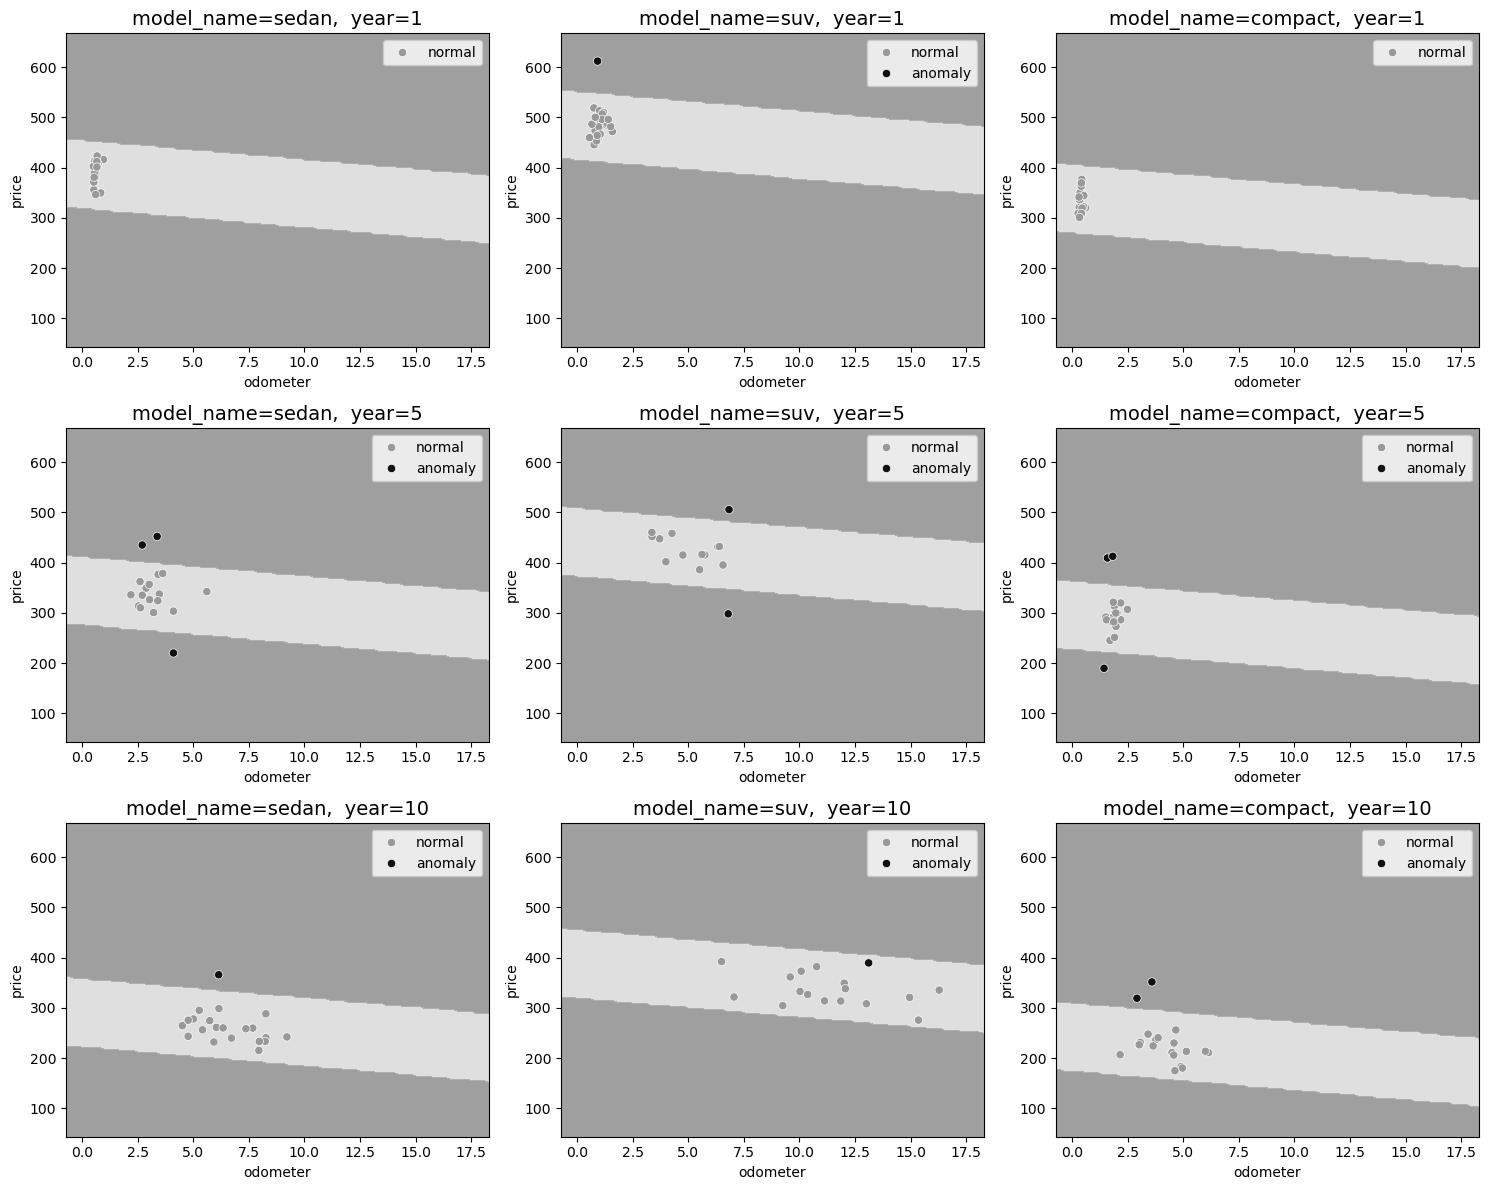

In [30]:
# 決定境界をプロット
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

###### 正常と異常の範囲を色分け ######
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
df_X_test = df_encoded[['year', 'odometer'] + model_cat_names]
X_test_with_dropped = df_X_test.copy()
X_test_with_dropped[f'model_name_{droped_model_name}'] = (df_test['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names+[f'model_name_{droped_model_name}']):
    df_test_model = df_test[X_test_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        df_test_year = df_test_model[df_test_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(df_X_test['odometer']), np.max(df_X_test['odometer'])
        y_min, y_max = np.min(y_test), np.max(y_test)
        x_grid = np.linspace(x_min-1, x_max+2, num=100)
        y_grid = np.linspace(y_min-50, y_max+50, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        XY_grid = np.c_[X.ravel(), Y.ravel()]
        # 格子点の説明変数データに車種とyearを追加
        X_all_grid = XY_grid[:, 0].reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_all_grid = np.insert(X_all_grid, i_model+1, 1, axis=1)
            else:
                X_all_grid = np.insert(X_all_grid, i_model+1, 0, axis=1)
        X_all_grid = np.insert(X_all_grid, 0, year, axis=1)  # year
        # 異常度を算出
        anomaly_scores_grid = (XY_grid[:, 1]-w@X_all_grid.T-w_0)**2 / sigma2
        # しきい値判定
        pred_grid = np.where(anomaly_scores_grid > a_th, 0, 1)
        # 正常と異常の境界をプロット
        pred_pivot = pred_grid.reshape(X.shape)
        axes[year_idx][model_idx].contourf(X, Y, pred_pivot, levels=1,
                            cmap=cm.gray, alpha=0.5)

        ###### 各データを散布図としてプロット ######
        sns.scatterplot(data=df_test_year, x='odometer', y='price',
                        hue='label', palette=['#999999', '#111111'], ax=axes[year_idx][model_idx])
        # 図タイトルと凡例を追加
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
        axes[year_idx][model_idx].legend()
# グラフを表示
plt.tight_layout()
plt.show()

散布図がテストデータ（凡例の色分けが正解ラベル）、背景の塗りつぶしがモデルの予測結果（決定境界）を表しており、両者の判定が一致しているほど性能が高いと言えます。図からこのモデルは正解と判定の一致度が高いことが見てとれるため、良い性能指標の算出が期待されます。

### 参考：混同行列の計算

scikit-learnの[sklearn.metrics.confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)関数で混同行列を求めます

In [31]:
# 混同行列の計算
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, pred, labels=['normal', 'anomaly'])
cm_df = pd.DataFrame(cm, index=['normal', 'anomaly'], columns=['pred_normal', 'pred_anomaly'])
cm_df

,pred_normal,pred_anomaly
normal,500,0
anomaly,4,46


TP,TNの割合が非常に高く、FP、すなわち正常を異常と誤判定した誤報データは一例も観測されていません。またFN、すなわち異常を正常と判定した見逃しデータが4例のみ観測されています。

### 精度（Accuracy）

scikit-learnの[sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)関数で精度を求めます。

In [32]:
# 精度の計算
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.993


大半の判定が正しいので、精度が1.0（100%）に近い非常に良い値となっていることが分かります。

### 適合率（precision）

scikit-learnの[sklearn.metrics.precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)関数で適合率を求めます。

In [33]:
# 適合率の計算
from sklearn.metrics import precision_score

precision = precision_score(true_labels, pred, pos_label='anomaly')
print(f"Precision: {precision:.3f}")

Precision: 1.000


FP（誤報）が全く発生していないので、適合率が1.0（100%）となっていることが分かります。

### 再現率（recall）

scikit-learnの[sklearn.metrics.recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)関数で再現率を求めます。

In [34]:
# 再現率の計算
from sklearn.metrics import recall_score

recall = recall_score(true_labels, pred, pos_label='anomaly')
print(f"Recall: {recall:.3f}")

Recall: 0.920


FN（見逃し）は4例存在するので、再現率が1.0（100%）にはなっていませんが、1.0に近い良い値となっていることが分かります。

### F値（F-score）

scikit-learnの[sklearn.metrics.f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)関数でF値を求めます。

In [35]:
# F値の計算
from sklearn.metrics import f1_score

f1 = f1_score(true_labels, pred, pos_label='anomaly')
print(f"F1 Score: {f1:.3f}")

F1 Score: 0.958


F値も1.0（100%）に近い良好な値となっています

### AU-ROC

AU-ROCを求めるための前段階として、まずscikit-learnの[sklearn.metrics.roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)関数でROC曲線を求めて可視化します。

`precision_recall_curve`の第2引数には、しきい値判定の対象となる連続値のスコアとして異常度（`anomaly_scores`）を渡します。

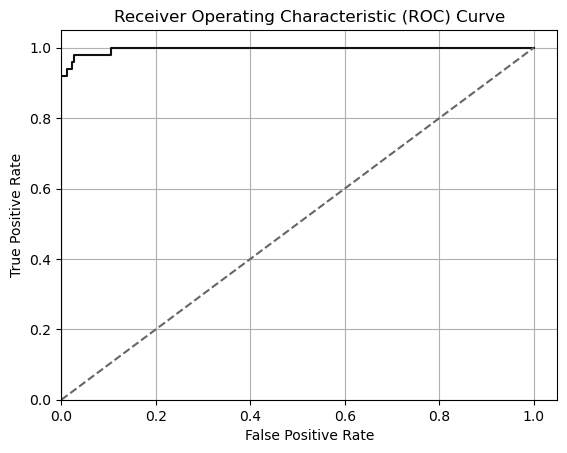

In [36]:
# ROC曲線の計算と可視化
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(true_labels, anomaly_scores, pos_label='anomaly')
plt.plot(fpr, tpr, color='#111111', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='#666666', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid()
plt.show()

ROC曲線は左上端に近い部分を通っており、良好な性能を表す形状となっています。

ここから[sklearn.metrics.auc](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html)関数でAU-ROCを求めます。

In [37]:
# AU-ROC の計算
from sklearn.metrics import auc

auroc = auc(fpr, tpr)
print(f"Area Under the ROC Curve (AU-ROC): {auroc:.4f}")

Area Under the ROC Curve (AU-ROC): 0.9967


ROC曲線の形状から推測される結果と同様、AU-ROCも1.0に近い良好な値となっています。

## 4. ベイズ統計モデリング（PyMC）を用いる場合

この例では、8章で解説したベイズ統計モデリング（PyMCによるベイズ推定ベースの回帰的手法）を用いるケースを想定します。

ここでは、7章で作成したサンプルデータと、8章で解説したベイズ線形回帰モデルを用います。以下に示すように、[ch8_4_Bayesian_Linear_Regression.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch8_4_Bayesian_Linear_Regression.ipynb)の手順（異常度ではなく、応答変数$y$に直接しきい値を設ける実装を採用します）で学習データを用いて学習したモデルを用い、推論用データを指標算出用のテストデータとして使用します。

In [38]:
# 性能評価指標算出に使用するデータとモデル
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import pymc as pm
import arviz as az
import xarray as xr
from scipy import stats

TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）

# 学習データ読み込み
df_train = pd.read_csv('./datasets/usedcar_dataset_train.csv')
df_normal = df_train[df_train['label'] == 'normal']  # 正常データのみを抽出
# カテゴリ変数'model_name'の数値化（one-hot encoding）
enc = OneHotEncoder(drop='first')
model_name_cat = enc.fit_transform(df_normal[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_normal.drop('model_name', axis=1), df_model_name], axis=1)
# 学習データの説明変数と応答変数（'price'）を別々に保持してndarray化
X_train = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_train = df_encoded['price'].to_numpy()
# モデルの学習
seed=42 # 乱数シードを指定（結果の再現性を担保）
multi_regression_model = pm.Model()
with multi_regression_model:
    # 事前分布（無情報に近づくよう分散の広い分布を使用する）
    w_0 = pm.Normal("w_0", mu=0, sigma=100)
    w = pm.Normal("w", mu=0, sigma=100, shape=4)
    sigma = pm.HalfNormal("sigma", sigma=100)
    # 線形予測子
    mu = w_0 + w[0]*X_train[:, 0] + w[1]*X_train[:, 1] \
        + w[2]*X_train[:, 2] + w[3]*X_train[:, 3]
    # 確率分布
    y = pm.Normal("y", mu=mu, sigma=sigma, observed=y_train)
    # MCMCの実行（学習）
    with multi_regression_model:
        trace = pm.sample(random_seed=seed)
# 各パラメータのMCMCサンプルの概要を表示
print(az.summary(trace, round_to=2))
# MCMCサンプルを保持
posterior_mcmc = trace.posterior

# CSVからPandas DataFrameにテストデータ読み込み
df_test = pd.read_csv('./datasets/usedcar_dataset_inference.csv')
true_labels = df_test['label'].to_numpy()  # 正解ラベルを保持
# カテゴリ変数'model_name'の数値化（one-hot encoding）
model_name_cat = enc.transform(df_test[['model_name']].to_numpy()).toarray()
model_cat_names = [f'model_name_{col}' for col in enc.categories_[0][1:]]
df_model_name = pd.DataFrame(model_name_cat, columns=model_cat_names)
df_encoded = pd.concat([df_test.drop('model_name', axis=1), df_model_name], axis=1)
# テストデータの説明変数（'year'）と応答変数（'price'）をNumpyのndarray化
X_test = df_encoded[['year', 'odometer']+model_cat_names].to_numpy()
y_test = df_encoded['price'].to_numpy()
# 平均パラメータmuの事後分布のMCMCサンプルを計算
X_test_xr = xr.DataArray(X_test, dims=["record", "w_dim_0"])
mu_posterior_test = posterior_mcmc["w_0"]*xr.DataArray(np.ones(X_test.shape[0]), dims=["record"]) \
    + xr.dot(posterior_mcmc["w"], X_test_xr, dim=["w_dim_0"])
# 推論データから予測分布のMCMCサンプルを計算し、しきい値判定
sigma_posterior = posterior_mcmc["sigma"].to_numpy() # σの事後分布
predictions = []
for i, y in enumerate(y_test): # データごとに予測分布を計算
    mu_posterior_i = mu_posterior_test[:, :, i].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.norm.rvs(
        loc=mu_posterior_i,
        scale=sigma_posterior,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # 下側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
    th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
    # 上側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
    th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
    # しきい値判定
    pred = np.where((y < th_lower) | (y > th_upper), 'anomaly', 'normal')
    predictions.append(str(pred))
predictions = np.array(predictions)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w_0, w, sigma]


Output()

/Users/knakamura/miniforge3/envs/anomaly_detection/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


         mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
w_0    348.56  2.28  344.25   352.88       0.06     0.04   1537.97   2278.80   
w[0]   -10.68  0.51  -11.70    -9.76       0.01     0.01   1327.48   1890.25   
w[1]    -3.77  0.65   -4.96    -2.53       0.02     0.01   1321.31   2066.43   
w[2]    48.52  2.08   44.63    52.44       0.05     0.03   1787.90   2155.56   
w[3]   145.38  3.14  139.86   151.46       0.09     0.05   1325.09   2233.66   
sigma   24.74  0.56   23.65    25.77       0.01     0.01   2890.87   2342.65   

       r_hat  
w_0      1.0  
w[0]     1.0  
w[1]     1.0  
w[2]     1.0  
w[3]     1.0  
sigma    1.0  


参考として、テストデータと学習済みモデルの決定境界をプロットしてみます。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_95814/3286007388.py:68: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=df_inference_year, x='odometer', y='price',
/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_95814/3286007388.py:68: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(data=df_inference_year, x='odometer', y='price',


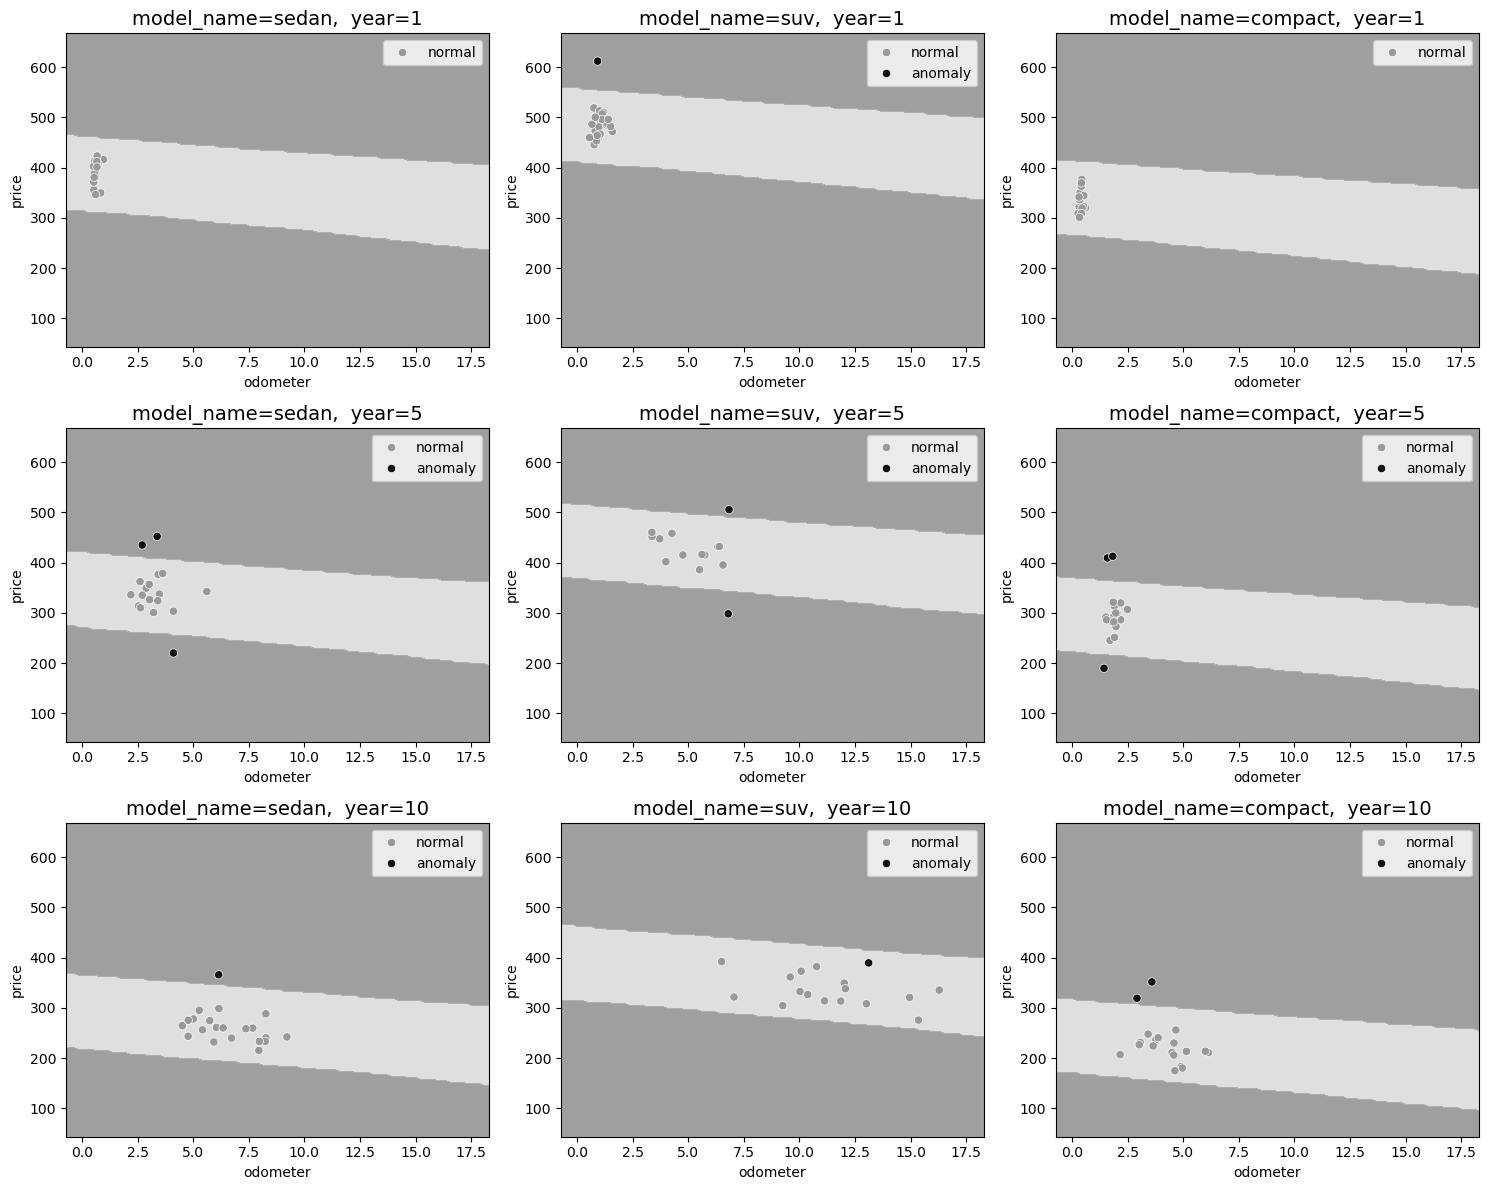

In [39]:
# 決定境界をプロット
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

# 描画用のFigureとAxesを生成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

###### 正常と異常の範囲を色分け ######
# 削除したカテゴリの列を表示用に追加する
droped_model_name = enc.categories_[0][0]
df_X_inference = df_encoded[['year', 'odometer']+model_cat_names]
X_inference_with_dropped = df_X_inference.copy()
X_inference_with_dropped[f'model_name_{droped_model_name}'] = (df_test['model_name'] == droped_model_name).astype('float64')
# 車種ごとに図を分ける
for model_idx, model_cat_name in enumerate(model_cat_names+[f'model_name_{droped_model_name}']):
    df_inference_model = df_test[X_inference_with_dropped[model_cat_name] == 1]
    # yearごとに図を分ける
    for year_idx, year in enumerate([1, 5, 10]):
        df_inference_year = df_inference_model[df_inference_model['year'] == year]
        ###### 確率密度関数を描画 ######
        # (x,y)格子点を作成
        x_min, x_max = np.min(df_X_inference['odometer']), np.max(df_X_inference['odometer'])
        y_min, y_max = np.min(y_test), np.max(y_test)
        x_grid = np.linspace(x_min-1, x_max+2, num=100)
        y_grid = np.linspace(y_min-50, y_max+50, num=200)
        X, Y = np.meshgrid(x_grid, y_grid)
        # 格子点の説明変数データに車種とyearを追加
        X_grid = x_grid.reshape(-1, 1)
        for i_model in range(len(model_cat_names)):
            if i_model == model_idx:
                X_grid = np.insert(X_grid, i_model+1, 1, axis=1)
            else:
                X_grid = np.insert(X_grid, i_model+1, 0, axis=1)
        X_grid = np.insert(X_grid, 0, year, axis=1)  # year
        # 平均パラメータmuの事後分布のMCMCサンプルを計算
        X_grid_xr = xr.DataArray(X_grid, dims=["x_odometer", "w_dim_0"])
        mu_posterior = posterior_mcmc["w_0"] * xr.DataArray(np.ones(X_grid.shape[0]), dims=["x_odometer"]) \
            + xr.dot(posterior_mcmc["w"], X_grid_xr, dim=["w_dim_0"])
        sigma_posterior = posterior_mcmc["sigma"].to_numpy()  # σの事後分布
        # xの値ごとに予測分布を計算
        pdf_all_grid = []
        pred_all_grid = []
        for x_idx, x_i in enumerate(x_grid):
            mu_posterior_i = mu_posterior[:, :, x_idx].to_numpy()
            # 予測分布のMCMCサンプルを計算
            posterior_predictive = stats.norm.rvs(
                loc=mu_posterior_i,
                scale=sigma_posterior,
                size=mu_posterior_i.shape,
                random_state=seed
            )
            # 下側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
            th_lower = np.quantile(posterior_predictive, TARGET_FP_RATE/2)
            # 上側しきい値（MCMCサンプルの、ターゲットとする誤報率と等しい分位点）
            th_upper = np.quantile(posterior_predictive, 1 - TARGET_FP_RATE/2)
            # しきい値判定
            pred = np.where((y_grid < th_lower) | (y_grid > th_upper), 0, 1)
            # データを保持
            pred_all_grid.append(pred)
        pred_all_pivot = np.array(pred_all_grid).T
        # 正常と異常の境界をプロット
        axes[year_idx][model_idx].contourf(X, Y, pred_all_pivot, levels=1,
                            cmap=cm.gray, alpha=0.5)

        ###### 各データを散布図としてプロット ######
        sns.scatterplot(data=df_inference_year, x='odometer', y='price',
                        hue='label', palette=['#999999', '#111111'], ax=axes[year_idx][model_idx])
        # 図タイトルと凡例を追加
        axes[year_idx][model_idx].set_title(f'{model_cat_name.replace("name_", "name=")},  year={year}', fontsize=14)
        axes[year_idx][model_idx].legend()
# グラフを表示
plt.tight_layout()
plt.show()

散布図がテストデータ（凡例の色分けが正解ラベル）、背景の塗りつぶしがモデルの予測結果（決定境界）を表しており、両者の判定が一致しているほど性能が高いと言えます。図からこのモデルは正解と判定の一致度が高いことが見てとれるため、良い性能指標の算出が期待されます。

### 参考：混同行列の計算

scikit-learnの[sklearn.metrics.confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)関数で混同行列を求めます

In [40]:
# 混同行列の計算
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predictions, labels=['normal', 'anomaly'])
cm_df = pd.DataFrame(cm, index=['normal', 'anomaly'], columns=['pred_normal', 'pred_anomaly'])
cm_df

,pred_normal,pred_anomaly
normal,500,0
anomaly,7,43


TP,TNの割合が高く、FP、すなわち正常を異常と誤判定した誤報データは一例も観測されていません。またFN、すなわち異常を正常と判定した見逃しデータが7例観測されています。

### 精度（Accuracy）

scikit-learnの[sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)関数で精度を求めます。

In [41]:
# 精度の計算
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.987


FN（見逃し）はある程度発生していますが、FP（誤報）が全く発生していないので、見逃しに鈍感な精度は1.0（100%）に近い非常に良い値となっていることが分かります。

### 適合率（precision）

scikit-learnの[sklearn.metrics.precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)関数で適合率を求めます。

In [42]:
# 適合率の計算
from sklearn.metrics import precision_score

precision = precision_score(true_labels, predictions, pos_label='anomaly')
print(f"Precision: {precision:.3f}")

Precision: 1.000


FP（誤報）が全く発生していないので、適合率が1.0（100%）となっていることが分かります。

### 再現率（recall）

scikit-learnの[sklearn.metrics.recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)関数で再現率を求めます。

In [43]:
# 再現率の計算
from sklearn.metrics import recall_score

recall = recall_score(true_labels, predictions, pos_label='anomaly')
print(f"Recall: {recall:.3f}")

Recall: 0.860


FN（見逃し）は7例存在するので、再現率が0.86（86%）となっています。

### F値（F-score）

scikit-learnの[sklearn.metrics.f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)関数でF値を求めます。

In [44]:
# F値の計算
from sklearn.metrics import f1_score

f1 = f1_score(true_labels, predictions, pos_label='anomaly')
print(f"F1 Score: {f1:.3f}")

F1 Score: 0.925


見逃しがやや多いことを反映して、正解率よりもF値が低い値となっています。

### AU-ROC

AU-ROCを求めるための前段階として、まずscikit-learnの[sklearn.metrics.roc_curve](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)関数でROC曲線を求めて可視化します。

`precision_recall_curve`の第2引数には、しきい値判定の対象となる連続値のスコアを渡します。今回は異常度を求めず応答変数$y$に直接しきい値を設けているので、このしきい値判定に対応し、かつ統計的に妥当性のある連続値を求める必要があります。

今回のしきい値判定では、各データの応答変数$y$が、予測分布のMCMCサンプルにおいて何%分位点に相当するかを求め、この分位点が「ターゲットとする誤報率」または「1-ターゲットとする誤報率」よりも外側にあれば異常と判定していました。
これは、「観測された応答変数**$y$が予測分布のもとでどれくらい両側の裾に属するか」、すなわち予測分布において$y$よりも外側に属する確率である、両側の尾部確率（tail probability）を判定に用いることに相当します。

今回のケースでは、予測分布の各MCMCサンプル$y_p^{(t)}$から尾部確率を求めます。$y$よりも上側、下側にあるMCMCサンプルの割合$p_{\mathrm{upper}}(y),p_{\mathrm{lower}}(y)$は、以下のように表されます（$\{\cdot\}$は、条件$\cdot$を満たすとき1、そうでないとき0となる関数）

$p_{\mathrm{upper}}(y)=\frac{1}{L} \sum_{t=1}^{L} \{y_p^{(t)} \geq y\}$

$p_{\mathrm{lower}}(y)=\frac{1}{L} \sum_{t=1}^{L} \{y_p^{(t)} \leq y\}$

このとき、両側の尾部確率$p_{\mathrm{two-sided}}$は以下のように求められます。

$p_{\mathrm{two-sided}}=2\min(p_{\mathrm{upper}}(y),p_{\mathrm{lower}}(y))$

$p_{\mathrm{two-sided}}$は小さいほど異常度合いが高い（珍しい値）とみなせるので、逆数をとった

$\mathrm{score} = 1 - p_{\mathrm{two-sided}}$

をスコアとして用います。

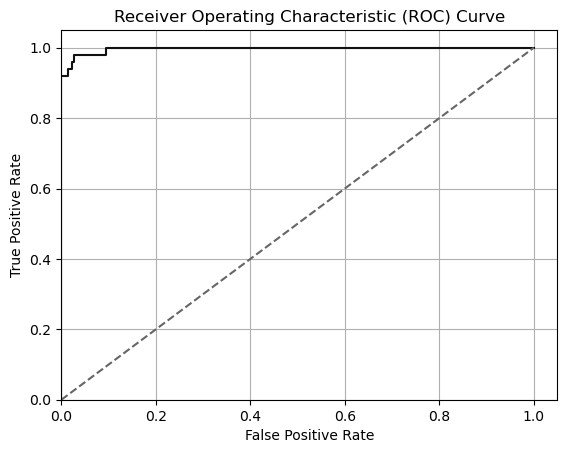

In [45]:
# ROC曲線の計算と可視化
from sklearn.metrics import roc_curve

# 予測分布のMCMCサンプルにおいて応答変数yの両側尾部確率を計算し、スコアとする
y_score = []
for i, y in enumerate(y_test): # データごとに予測分布を計算
    mu_posterior_i = mu_posterior_test[:, :, i].to_numpy()
    # 予測分布のMCMCサンプルを計算
    posterior_predictive = stats.norm.rvs(
        loc=mu_posterior_i,
        scale=sigma_posterior,
        size=mu_posterior_i.shape,
        random_state=seed
    )
    # 両側尾部確率を計算
    p_lower = np.mean(posterior_predictive <= y)
    p_upper = np.mean(posterior_predictive >= y)
    p_twosided = 2 * min(p_lower, p_upper)
    # スコアに変換
    score = 1 - p_twosided
    y_score.append(score)

fpr, tpr, thresholds_roc = roc_curve(true_labels, y_score, pos_label='anomaly')
plt.plot(fpr, tpr, color='#111111', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='#666666', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])
plt.grid()
plt.show()

ROC曲線は左上端に近い部分を通っており、良好な性能を表す形状となっています。

ここから[sklearn.metrics.auc](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html)関数でAU-ROCを求めます。

In [46]:
# AU-ROC の計算
from sklearn.metrics import auc

auroc = auc(fpr, tpr)
print(f"Area Under the ROC Curve (AU-ROC): {auroc:.4f}")

Area Under the ROC Curve (AU-ROC): 0.9969


ROC曲線の形状から推測される結果と同様、AU-ROCも1.0に近い良好な値となっています。